# AG-HYPOPT · Trial 08

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Seven trials recorded: trial_01 0.1907, trial_02 0.2075, trial_03 0.2472, trial_04 0.1987, trial_05 0.1863 (best), trial_06 0.2203, trial_07 0.1940. Same two facts throughout: mu_fit is near half of mu_true for every config (the objective floor), and the objective spread is driven by the gamma term, dominated by the low-transmission (Trans05) estimate. gamma_anneal is the most consistent lever: near-zero anneal gave the worst trial (trial_03), and the strong-anneal configs (0.6-0.74: trials 04/05/07) are the best. TPE (7/5) is now ranking candidates well; its top-EI picks have also begun to favor higher anneal. Context only.


In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_08'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 20    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (7/5 trials)
ID |     ei | params
 1 | 3.3436 | {"gamma_anneal": 0.7404576325034442, "lr_gamma": 0.8308391486560232, "lr_mu": 7.745243306077349, "sigma_ref": 16.75620838220414}
 2 | 2.6092 | {"gamma_anneal": 0.35922409062203775, "lr_gamma": 0.4057161988409038, "lr_mu": 9.846613722607767, "sigma_ref": 25.0}
 3 | 3.4921 | {"gamma_anneal": 0.4431771388240587, "lr_gamma": 0.828822232632601, "lr_mu": 9.777387409862962, "sigma_ref": 13.150452693008862}
 4 | 0.4952 | {"gamma_anneal": 0.13616545302204713, "lr_gamma": 0.8590825424307106, "lr_mu": 25.22816081747777, "sigma_ref": 5.0}
 5 | 0.7283 | {"gamma_anneal": 0.24696703253381538, "lr_gamma": 0.4926719317342368, "lr_mu": 13.801386245047414, "sigma_ref": 15.95054293849547}
 6 | 2.9202 | {"gamma_anneal": 0.29587687970150683, "lr_gamma": 0.8856464173960362, "lr_mu": 17.759614702963315, "sigma_ref": 25.0}
 7 | 3.2536 | {"gamma_anneal": 0.5861773327687287, "lr_gamma": 0.8505319929124843, "lr_mu": 12.20451507902337, "sigma_ref": 17

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

TPE (7/5) ranks by expected improvement. The highest-EI candidate is candidate 1 (EI 3.34) and, unlike earlier rounds, it also sits in the regime the evidence favors: a strong gamma_anneal (0.740 -- the highest in this slate, and past the 0.6-0.7 band that gave the best trials) with lr_gamma 0.831 and moderate sigma_ref 16.76 / lr_mu 7.75. The runner-up candidates 3 and 8 have similar lr_gamma but weaker anneal (0.44/0.46), and the boundary candidates (2, 6) push sigma_ref to 25.0. So the top-EI pick is also the most consistent with the campaign's clearest finding, which makes the choice unambiguous. I choose candidate 1.


In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 1               # highest-EI TPE pick, also in the strong-anneal regime


chosen: {'gamma_anneal': 0.7404576325034442, 'lr_gamma': 0.8308391486560232, 'lr_mu': 7.745243306077349, 'sigma_ref': 16.75620838220414}
Running  1nW Trans05 ... 

μ 9.39 -> 4.72 | γ 8.5 -> 4.84 | NLL 1.30


Running  1nW Trans20 ... 

μ 17.32 -> 8.60 | γ 8.5 -> 3.44 | NLL 2.81


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 50.55 | γ 14.1 -> 13.46 | NLL 3.13


Running 3nW Trans100 ... 

μ 175.71 -> 85.66 | γ 14.1 -> 13.82 | NLL 3.02



Total: 2.5 min


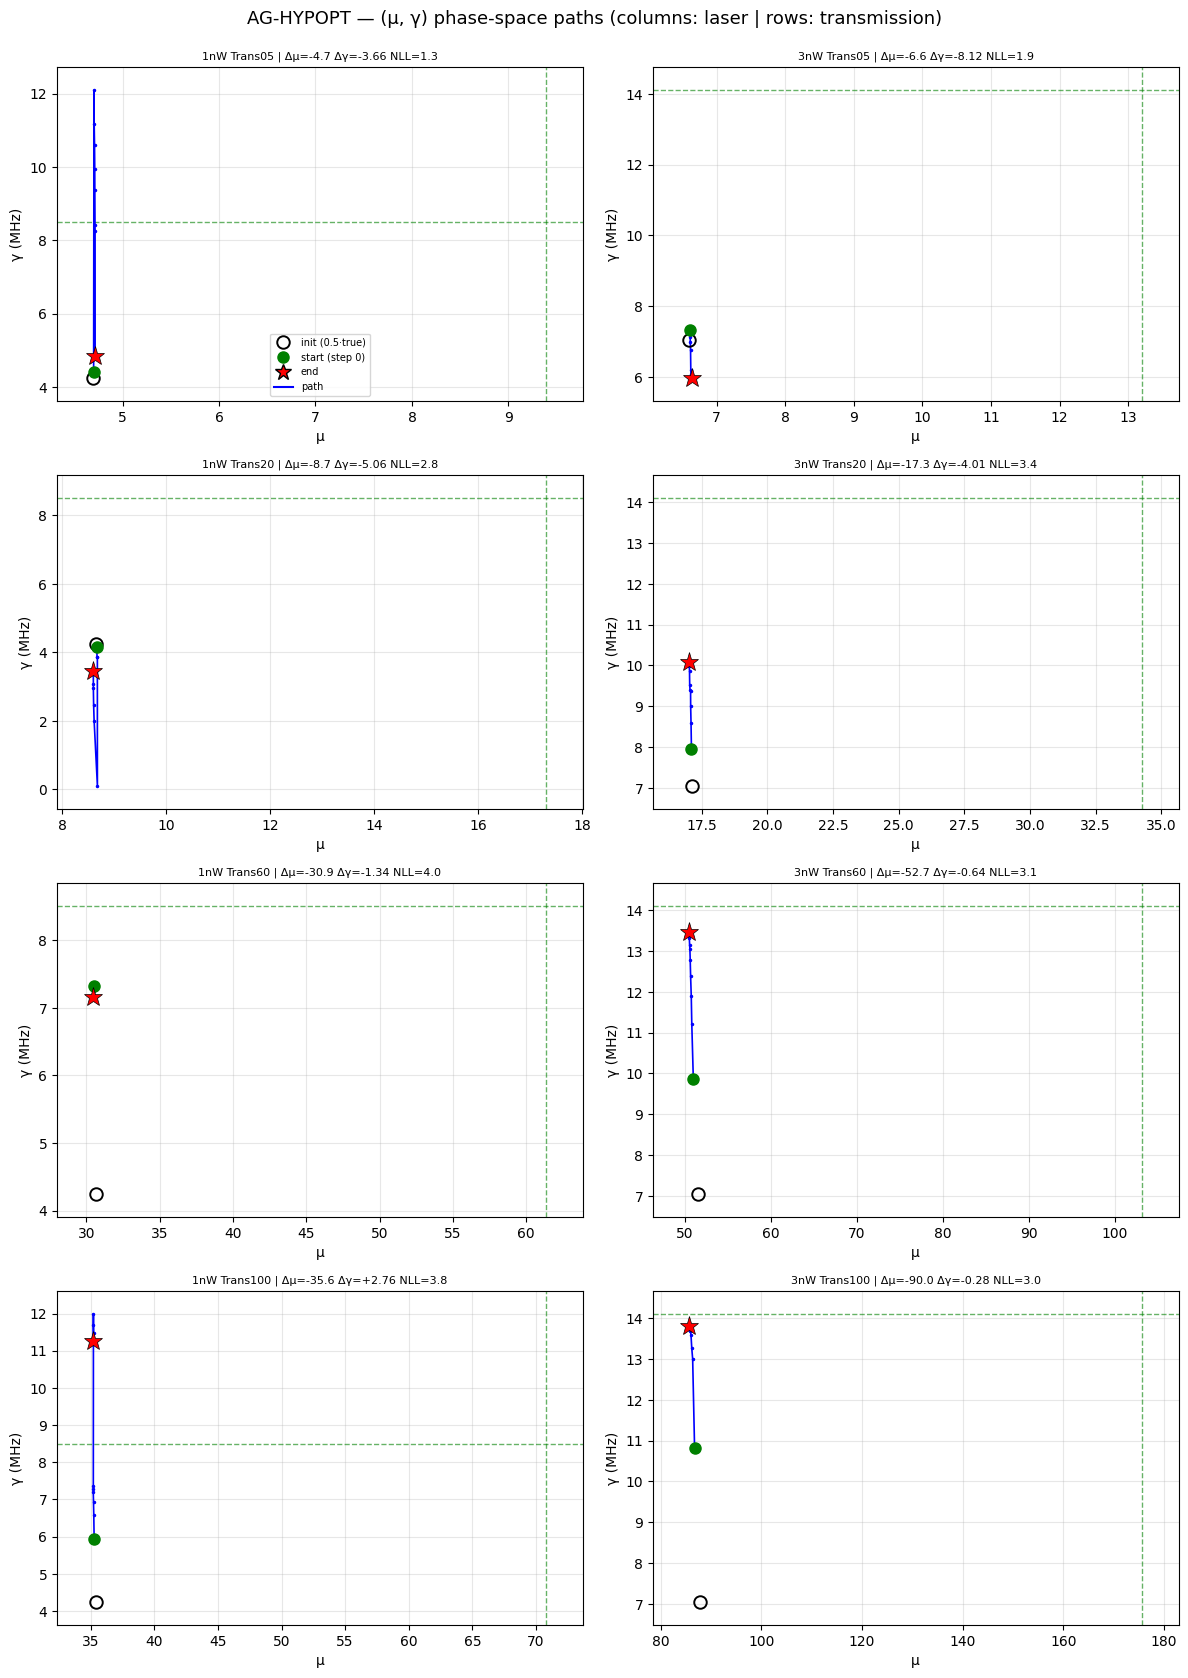

trial finished in 2.5 min
objective = 0.1948 ± 0.0286
exp           μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05     9.39    4.72   -49.8 |     8.50    4.84   -43.1
1nW Trans20    17.32    8.60   -50.3 |     8.50    3.44   -59.5
1nW Trans60    61.37   30.48   -50.3 |     8.50    7.16   -15.7
1nW Trans100   70.82   35.20   -50.3 |     8.50   11.26   +32.5
3nW Trans05    13.20    6.64   -49.7 |    14.10    5.98   -57.6
3nW Trans20    34.28   17.02   -50.4 |    14.10   10.09   -28.5
3nW Trans60   103.20   50.55   -51.0 |    14.10   13.46    -4.5
3nW Trans100  175.71   85.66   -51.2 |    14.10   13.82    -2.0

μ: RMSE 41.143 (rel 50.4%, bias -30.804) | γ: RMSE 4.046 (rel 36.8%, bias -2.542)


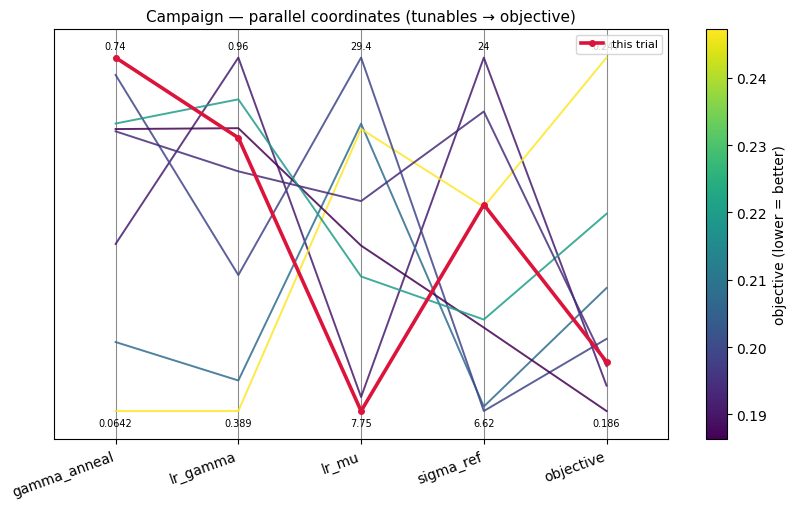

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Trial 08, third TPE-driven trial; highest-EI pick, also in the strong-anneal regime: sigma_ref 16.76, lr_mu 7.75, lr_gamma 0.831, gamma_anneal 0.740 (highest anneal tested). Result: objective 0.1948 +/- 0.0286, fourth-best of the campaign (behind trial_05 0.1863, trial_01 0.1907, trial_07 0.1940) and the smallest uncertainty so far; runtime 2.5 min. mu_fit is again near half of mu_true and extremely uniform (Delta-mu% -49.7 to -51.2; μ RMSE 41.14, relative 50.4%, bias -30.8 -- best mu RMSE so far, tied with trial_07). gamma_fit is good at high transmission (3 nW Trans60/100: -4.5/-2.0%) and even overshoots strongly at 1 nW Trans100 (+32.5%), but remains unstable at low/mid transmission (1 nW Trans05 -43.1%, 1 nW Trans20 -59.5%; 3 nW Trans05 -57.6%), gamma RMSE 4.05 (relative 36.8%). The highest anneal (0.740) still did not stabilise the low-transmission gamma.

**Summary:** Trial 08 (sigma_ref 16.76, lr_mu 7.75, lr_gamma 0.831, gamma_anneal 0.740) -> objective 0.1948 +/- 0.0286, fourth best (best mu RMSE, tightest CI); gamma near-truth/overshoots at high T but still unstable at low T.
**Key insight:** Anneal has been pushed to 0.740 without fixing the low-transmission gamma instability; the mu attractor stays at a very uniform half-truth, so both loss components now look resistant to further hyperparameter tuning.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
No new structural notes; the real-data attractor note from trial_01 still stands.


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = 'Trial 08 (sigma_ref 16.76, lr_mu 7.75, lr_gamma 0.831, gamma_anneal 0.740): objective 0.1948 +/- 0.0286, fourth best (best mu RMSE, tightest CI); gamma near-truth/overshoots at high T but still unstable at low T'
KEY_INSIGHT = 'Pushing anneal to 0.740 did not fix the low-transmission gamma instability, and the mu attractor stays at a very uniform half-truth -- both loss components now look resistant to further hyperparameter tuning.'


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_08 | current best: trial_05


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_09.ipynb. Open it and follow its cells from the top.
